# 第23篇｜分布探索：直方图 / KDE / 箱线图 / 小提琴图

> 这是「数据分析从入门到精通」系列的第 23 篇。Seaborn 入门了，这篇专门讲分布探索——直方图、KDE、箱线图、小提琴图，看懂数据的"长相"，是后续统计分析和建模的基础。

---

嗨，我是小荷～

拿到一份新数据，你的第一件事是什么？

不是建模，不是画折线，而是**看分布**。

分布能告诉你：数据的大致范围是多少？有没有极端值？数据是对称的还是偏斜的？不同组别之间差异大吗？

这些问题不清楚，后续所有分析都是在沙子上盖楼。今天这四种图——直方图、KDE、箱线图、小提琴图——是探索数据分布的四件套，每件都有自己的强项。

---

## 一、直方图（Histogram）

直方图把连续数据切成若干区间，统计每个区间的频率，是最基础的分布可视化方式。


In [1]:
import matplotlib.font_manager as fm

# matplotlib only know these fonts
font_list = [f for f in fm.fontManager.ttflist]

# check font names what you want
cjk_list = ['CJK', 'Han', 'CN', 'TW', 'Hei']

for f in font_list:
    if any(s.lower() in f.name.lower() for s in cjk_list):
        print(f'name={f.name}, path={f.fname}')


name=STIXSizeTwoSym, path=/root/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymReg.ttf
name=STIXSizeTwoSym, path=/root/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymBol.ttf
name=Noto Serif CJK JP, path=/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc
name=AR PL UKai CN, path=/usr/share/fonts/truetype/arphic/ukai.ttc
name=AR PL UMing CN, path=/usr/share/fonts/truetype/arphic/uming.ttc
name=Noto Serif CJK JP, path=/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc
name=WenQuanYi Micro Hei, path=/usr/share/fonts/truetype/wqy/wqy-microhei.ttc
name=Noto Sans CJK JP, path=/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
name=WenQuanYi Zen Hei, path=/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc
name=Noto Sans CJK JP, path=/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc


In [2]:
import matplotlib as mpl
import matplotlib.font_manager as fm
 
# 查看当前字体缓存目录
cache_dir = mpl.get_cachedir()
print(f"字体缓存目录: {cache_dir}")
 
# 查看已缓存的字体列表
font_list = fm.fontManager.ttflist
print(f"已缓存字体数量: {len(font_list)}")

print(mpl.matplotlib_fname())


字体缓存目录: /root/.cache/matplotlib
已缓存字体数量: 66
/root/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data/matplotlibrc


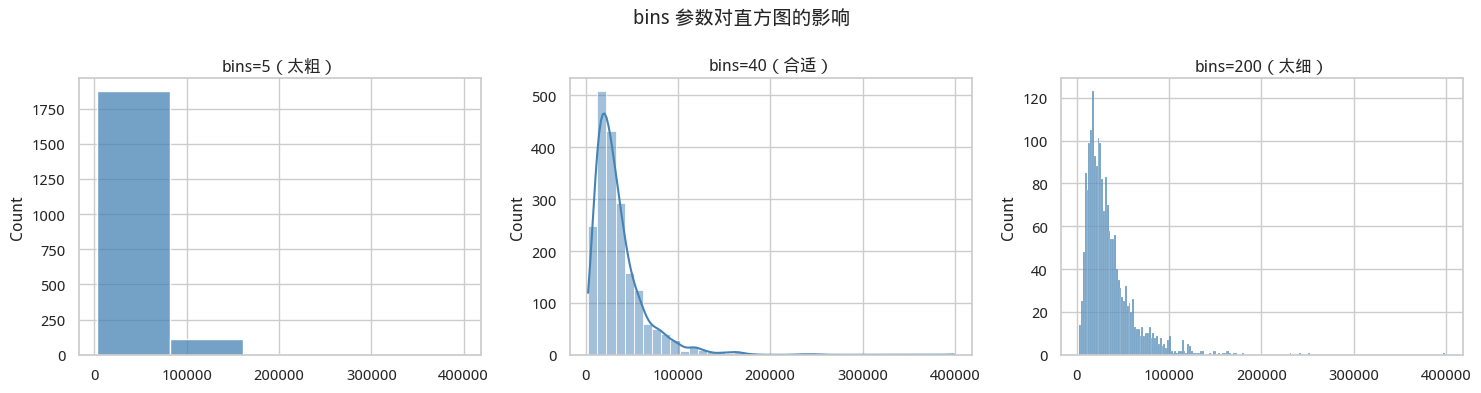

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(42)
income = np.random.lognormal(mean=10.2, sigma=0.7, size=2000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑

# bins 太少：看不清细节
sns.histplot(income, bins=5, ax=axes[0], color='steelblue')
axes[0].set_title('bins=5（太粗）')

# bins 合适：分布清晰
sns.histplot(income, bins=40, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('bins=40（合适）')

# bins 太多：噪声太多
sns.histplot(income, bins=200, ax=axes[2], color='steelblue')
axes[2].set_title('bins=200（太细）')

plt.suptitle('bins 参数对直方图的影响', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


> 💡 **bins 怎么选**：一般取 `int(n**0.5)` 到 `int(n**0.3 * 10)` 之间，或者直接用 `bins='auto'` 让 Numpy 自动计算。

### 分组直方图（比较两组分布）

来用代码感受概率分布的形状：


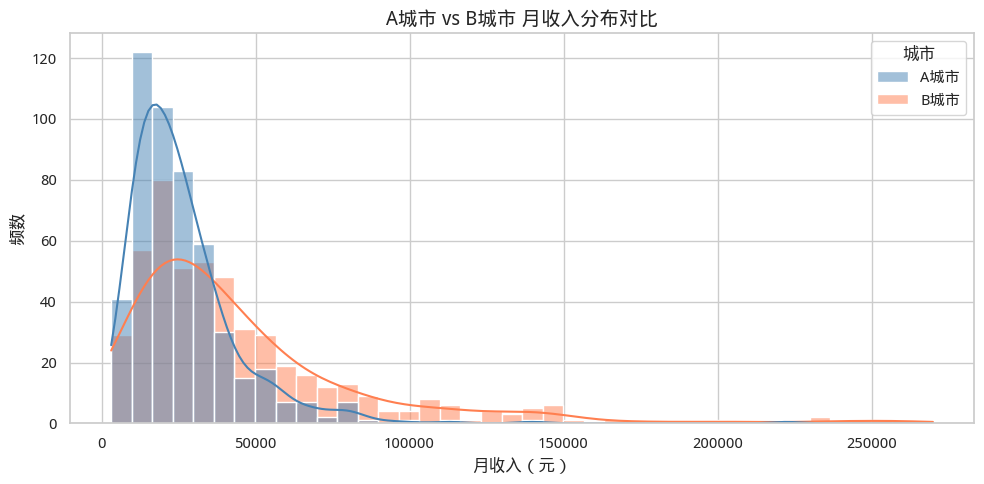

In [7]:
np.random.seed(42)
df_income = pd.DataFrame({
    '月收入': np.concatenate([
        np.random.lognormal(10.0, 0.6, 500),   # A城市
        np.random.lognormal(10.4, 0.8, 500)    # B城市
    ]),
    '城市': ['A城市'] * 500 + ['B城市'] * 500
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df_income, x='月收入', hue='城市',
              bins=40, kde=True, alpha=0.5, ax=ax,
              palette=['steelblue', 'coral'])

ax.set_title('A城市 vs B城市 月收入分布对比', fontsize=14, fontweight='bold')
ax.set_xlabel('月收入（元）')
ax.set_ylabel('频数')
plt.tight_layout()
plt.show()


---

## 二、核密度估计（KDE）

KDE 是直方图的"平滑版"，用连续曲线代替不连续的柱子，更适合比较多组分布的形态。


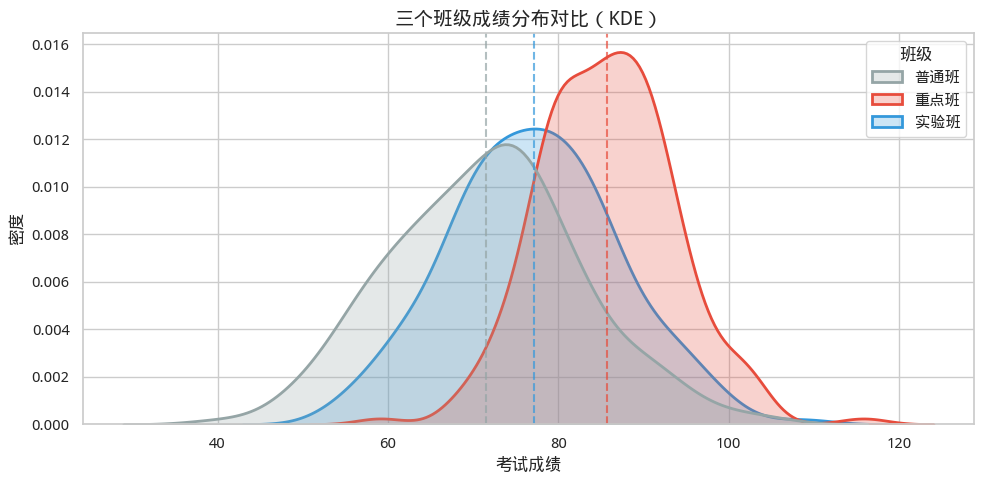

In [8]:
np.random.seed(42)
df_score = pd.DataFrame({
    '成绩': np.concatenate([
        np.random.normal(72, 12, 200),   # 普通班
        np.random.normal(85, 8, 200),    # 重点班
        np.random.normal(78, 10, 200)    # 实验班
    ]),
    '班级': ['普通班'] * 200 + ['重点班'] * 200 + ['实验班'] * 200
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df_score, x='成绩', hue='班级',
             fill=True, alpha=0.25, linewidth=2,
             palette=['#95A5A6', '#E74C3C', '#3498DB'], ax=ax)

# 标注均值
for label, color in [('普通班', '#95A5A6'), ('重点班', '#E74C3C'), ('实验班', '#3498DB')]:
    mean_val = df_score[df_score['班级'] == label]['成绩'].mean()
    ax.axvline(x=mean_val, color=color, linestyle='--', alpha=0.7, linewidth=1.5)

ax.set_title('三个班级成绩分布对比（KDE）', fontsize=14, fontweight='bold')
ax.set_xlabel('考试成绩')
ax.set_ylabel('密度')
plt.tight_layout()
plt.show()


---

## 三、箱线图（Box Plot）

箱线图用 5 个统计量描述分布：最小值、Q1（25%）、中位数（50%）、Q3（75%）、最大值，还能自动标出异常值。


In [ ]:
       ┌──────────┐
───────┤          ├───────  ← 须线（1.5×IQR范围）
       │  Q1      │
       │──────────│  ← 中位数
       │  Q3      │
       └──────────┘
           ●            ← 异常值（超出须线的点）


理解了箱线图的结构，咱们来用真实数据画一个：


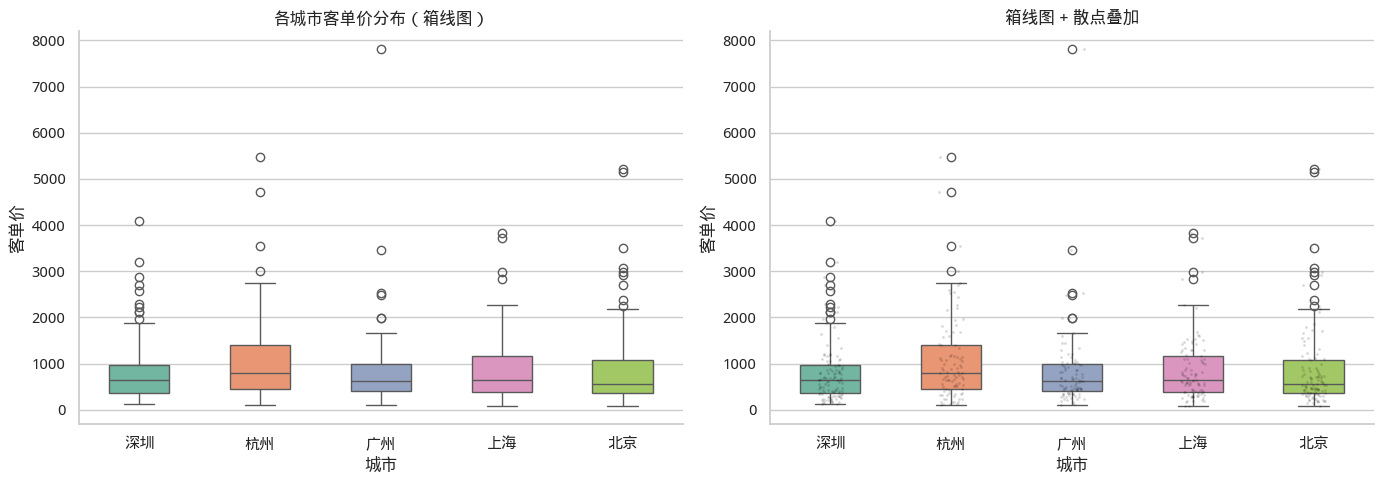

In [10]:
np.random.seed(42)
n = 500
df_box = pd.DataFrame({
    '城市':  np.random.choice(['北京', '上海', '广州', '深圳', '杭州'], n),
    '客单价': np.random.lognormal(6.5, 0.8, n)
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 基础箱线图
sns.boxplot(data=df_box, x='城市', hue='城市',y='客单价',legend=False,
             palette='Set2', width=0.5, ax=axes[0])
axes[0].set_title('各城市客单价分布（箱线图）', fontweight='bold')

# 叠加散点：看到原始数据密度
sns.boxplot(data=df_box, x='城市', hue='城市', y='客单价',legend=False,
             palette='Set2', width=0.5, ax=axes[1])
sns.stripplot(data=df_box, x='城市', y='客单价',
               color='black', alpha=0.15, size=2, ax=axes[1])
axes[1].set_title('箱线图 + 散点叠加', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---

## 四、小提琴图（Violin Plot）

小提琴图 = 箱线图 + KDE，既能看分布形态，又能看统计摘要，是箱线图的升级版：


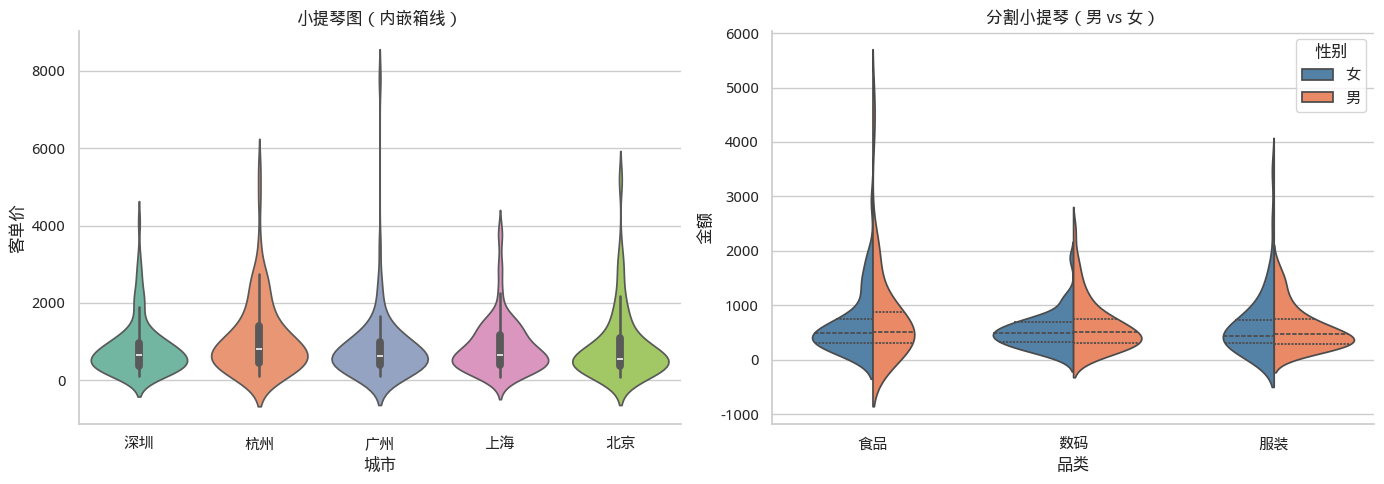

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 基础小提琴图
sns.violinplot(data=df_box, x='城市', hue='城市',y='客单价',legend=False,
                palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('小提琴图（内嵌箱线）', fontweight='bold')

# 分割小提琴（两组对比时很有用）
np.random.seed(42)
n2 = 300
df_gender = pd.DataFrame({
    '品类':  np.random.choice(['数码', '服装', '食品'], n2),
    '金额':  np.random.lognormal(6.2, 0.7, n2),
    '性别':  np.random.choice(['男', '女'], n2)
})

sns.violinplot(data=df_gender, x='品类', y='金额', hue='性别',
                split=True, palette=['steelblue', 'coral'],
                inner='quart', ax=axes[1])
axes[1].set_title('分割小提琴（男 vs 女）', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


`split=True` 让两组数据各占一半，对比非常直观。

---

## 五、四种图的选择指南

| 图表 | 看什么 | 适合场景 |
|------|--------|---------|
| 直方图 | 频率分布形态 | 单组数据，探索分布 |
| KDE | 平滑分布曲线 | 多组对比，分布形态 |
| 箱线图 | 中位数、四分位、异常值 | 多组对比，关注异常值 |
| 小提琴图 | 分布形态 + 统计摘要 | 多组对比，关注形态细节 |

**组合用法**：直方图+KDE（单组深入）、箱线图+散点（多组+原始数据）、分割小提琴（两组对比）。

---

## 六、🔧 综合实战：收入分布体检报告

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


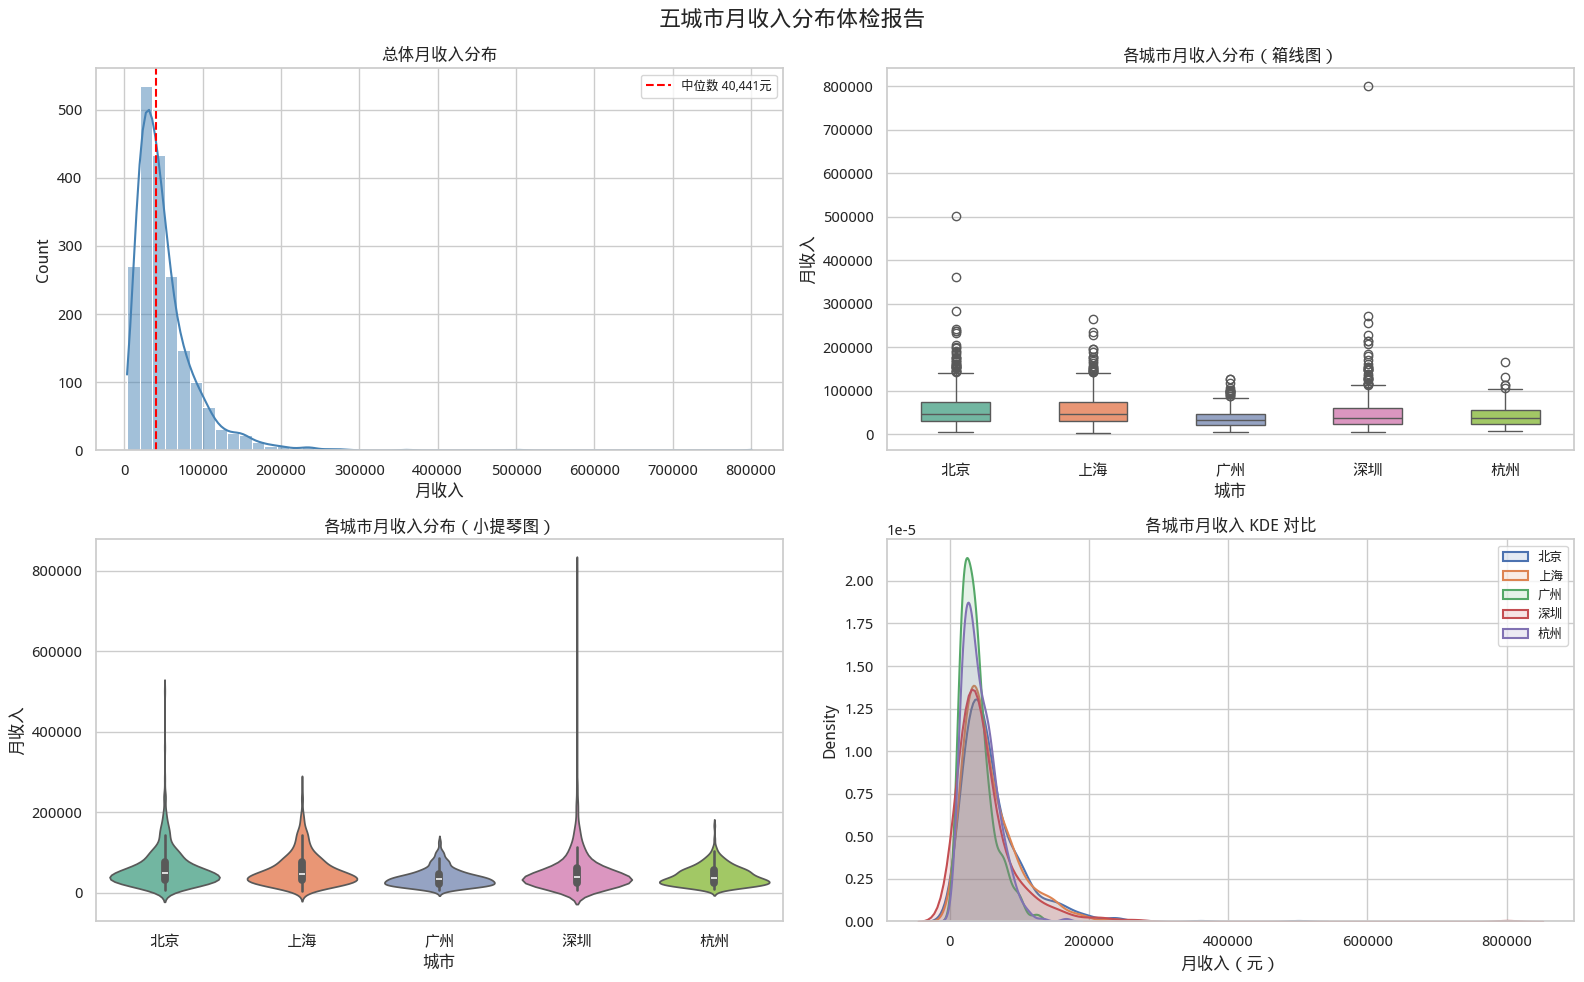


各城市收入统计摘要：
       均值    中位数    标准差     最大值
城市                             
上海  57849  46130  41042  265371
北京  61193  47578  48993  501063
广州  37835  33175  22422  126886
杭州  42719  37030  23942  166632
深圳  52293  38798  56000  800872


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(2024)
cities = ['北京', '上海', '广州', '深圳', '杭州']
incomes = {
    '北京': np.random.lognormal(10.8, 0.65, 500),
    '上海': np.random.lognormal(10.7, 0.70, 400),
    '广州': np.random.lognormal(10.4, 0.60, 350),
    '深圳': np.random.lognormal(10.6, 0.68, 380),
    '杭州': np.random.lognormal(10.5, 0.55, 300)
}
rows = []
for city, vals in incomes.items():
    for v in vals:
        rows.append({'城市': city, '月收入': v})
df = pd.DataFrame(rows)

fig = plt.figure(figsize=(16, 10))
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑

# ── 子图1：总体分布 ──
ax1 = fig.add_subplot(2, 2, 1)
sns.histplot(df['月收入'], bins=50, kde=True, color='steelblue', ax=ax1)
ax1.axvline(df['月收入'].median(), color='red', linestyle='--', label=f'中位数 {df["月收入"].median():,.0f}元')
ax1.set_title('总体月收入分布', fontweight='bold')
ax1.legend(fontsize=9)

# ── 子图2：各城市箱线图 ──
ax2 = fig.add_subplot(2, 2, 2)
sns.boxplot(data=df, x='城市',hue='城市', y='月收入', palette='Set2', width=0.5, ax=ax2,legend=False)
ax2.set_title('各城市月收入分布（箱线图）', fontweight='bold')

# ── 子图3：各城市小提琴图 ──
ax3 = fig.add_subplot(2, 2, 3)
sns.violinplot(data=df, x='城市',hue='城市', y='月收入', palette='Set2', inner='box', ax=ax3,legend=False,)
ax3.set_title('各城市月收入分布（小提琴图）', fontweight='bold')

# ── 子图4：各城市KDE对比 ──
ax4 = fig.add_subplot(2, 2, 4)
for city in cities:
    subset = df[df['城市'] == city]['月收入']
    sns.kdeplot(subset, label=city, fill=True, alpha=0.15, linewidth=1.5, ax=ax4)
ax4.set_title('各城市月收入 KDE 对比', fontweight='bold')
ax4.set_xlabel('月收入（元）')
ax4.legend(fontsize=9)

plt.suptitle('五城市月收入分布体检报告', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 统计摘要 ──
summary = df.groupby('城市')['月收入'].agg([
    ('均值', 'mean'), ('中位数', 'median'),
    ('标准差', 'std'), ('最大值', 'max')
]).round(0).astype(int)
print("\n各城市收入统计摘要：")
print(summary)


---

## 七、📝 小结

| 关键概念 | 含义 |
|---------|------|
| 正态分布 | 对称的钟形，均值=中位数 |
| 右偏分布 | 右侧长尾（收入、交易金额常见） |
| 异常值 | 箱线图须线以外的点 |
| IQR | Q3-Q1，四分位距，衡量中间 50% 数据的范围 |

---

## 八、🏋️ 课后练习

1. 对你实战项目的 `amount` 列画直方图+KDE，判断是正态分布还是右偏？
2. 用箱线图比较不同会员等级的消费金额，找出哪个等级的异常值最多。
3. 用小提琴图对比"数码"和"服装"两个品类的订单金额分布差异。

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 24 篇：关系探索 — 散点图 / 气泡图 / 相关热力图**
>
> 探索完单变量分布，下篇来看两变量关系——散点图、气泡图、相关热力图，找出变量之间的关键联系。

---

*跟着小荷，数据分析路上不迷路～*
